In [32]:
import os
os.environ["GYRO_DATA_DIR"] = "/home/Felix/Documents/Physics_Work/Project_Codes/Gyrokinetic_Simulations/"


In [33]:
import controller

In [34]:
tglf_list = ["tglf", "tglf_F", "tglf_M"]

In [41]:
from pathlib import Path

PROJECT_NAME = "Beta_Prime_Scan"
CASE = "R4"

# Use current working directory as root
REPO_ROOT = Path.cwd().parent  # adjust `.parent` depending on your folder structure

print(REPO_ROOT)

/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan


In [42]:
plot_location = REPO_ROOT / "Plots" / PROJECT_NAME / CASE

In [43]:

gs2_pyroscan,GS2_convention, tglf_pyroscan_dict = controller.load_list(CASE,PROJECT_NAME,tglf_list,read_netcdf=True,write_netcdf=False)

Loading GS2 PyroScan from: /home/Felix/Documents/Physics_Work/Project_Codes/Gyrokinetic_Simulations/GS2/Runs/Beta_Prime_Scan/R4/parameter_scan_gs2/ky_0.2154_beta_0.1200/gs2.in
see if that's geting called
see if that's geting called
what about this one
see if that's geting called
what about this one
see if that's geting called
what about this one


In [44]:
print(gs2_pyroscan.gk_output)

<pyrokinetics.PyroScanGKOutput>
(Wraps <xarray.Dataset>) Size: 1MB
Dimensions:                (ky: 4, beta: 19, field: 3, theta: 385, species: 2)
Coordinates:
  * field                  (field) <U4 48B 'phi' 'apar' 'bpar'
  * species                (species) <U8 64B 'electron' 'ion1'
  * ky                     (ky) float64 32B 0.1 0.2 0.3 0.4
  * beta                   (beta) float64 152B 0.008776 0.01755 ... 0.158 0.1667
  * theta                  (theta) float64 3kB -9.425 -9.392 ... 9.392 9.425
Data variables:
    growth_rate            (ky, beta) float64 608B [([tref] / [mref])**(0.5)/lref_minor_radius] ...
    mode_frequency         (ky, beta) float64 608B [([tref] / [mref])**(0.5)/lref_minor_radius] ...
    growth_rate_tolerance  (ky, beta) float64 608B [] 9.34e-08 ... 1.475e-06
    eigenfunctions         (ky, beta, field, theta) complex128 1MB [] (0.0014...
    particle               (ky, beta, field, species) float64 4kB [nref_electron·([tref] / [mref])**(0.5) * [mref] / [bref_

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def plot_growth_rate_difference(gs2_output, tglf_output, 
                                metric="absolute",
                                cmap="seismic",
                                ax=None):
    """
    Plot a beta–ky heatmap of the difference in growth rate between 
    a GS2 PyroScanGKOutput (ground truth) and a TGLF PyroScanGKOutput.
    
    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth simulation output.
    tglf_output : PyroScanGKOutput
        Model/surrogate output to compare.
    metric : {"absolute", "relative"}
        absolute  → Δγ = γ_tglf – γ_gs2
        relative  → Δγ/|γ_gs2|
    cmap : str
        Matplotlib colormap name.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 5))
    else:
        fig = ax.figure

    # Extract coordinates
    ky = gs2_output.coords["ky"].data
    beta = gs2_output.coords["beta"].data

    # Extract growth rate arrays (ky, beta)
    gr_gs2 = gs2_output["growth_rate"].values
    gr_tglf = tglf_output["growth_rate"].sel(mode=0).values

    # Compute difference metric
    if metric == "absolute":
        diff = (gr_tglf - gr_gs2)
    elif metric == "relative":
        diff = ((gr_tglf - gr_gs2) / np.abs(gr_gs2))
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    # Set symmetric color scale for diverging colormap
    #vmax = np.nanmax(np.abs(diff))
    vmax = 0.5
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # pcolormesh wants 2D coordinate grids
    ky_grid, beta_grid = np.meshgrid(ky, beta, indexing="ij")

    pcm = ax.pcolormesh(
        ky_grid, beta_grid, diff,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # Labels styled similar to your example figure
    ax.set_xlabel(r"$k_y$")
    ax.set_ylabel(r"$\beta$ (%)")
    #ax.set_xscale("log")   # optional — remove if desired

    # Colorbar above
    cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", location = "top")
    if metric == "absolute":
        cbar.set_label(r"$\Delta \gamma$", labelpad=6)
    else:
        cbar.set_label(r"$\Delta \gamma / |\gamma_{\mathrm{GS2}}|$", labelpad=6)
    plt.tight_layout()
    return fig, ax


def plot_growth_rate_difference_GP(gs2_output, tglf_output, 
                                metric="absolute",
                                cmap="seismic",
                                ax=None):
    """
    Plot a beta–ky heatmap of the difference in growth rate between 
    a GS2 PyroScanGKOutput (ground truth) and a TGLF PyroScanGKOutput.
    
    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth simulation output.
    tglf_output : PyroScanGKOutput
        Model/surrogate output to compare.
    metric : {"absolute", "relative"}
        absolute  → Δγ = γ_tglf – γ_gs2
        relative  → Δγ/|γ_gs2|
    cmap : str
        Matplotlib colormap name.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 5))
    else:
        fig = ax.figure

    # Extract coordinates
    ky = gs2_output.coords["ky"].data
    beta = gs2_output.coords["beta"].data

    # Extract growth rate arrays (ky, beta)
    gr_gs2 = gs2_output["growth_rate"].values
    gr_tglf = tglf_output["growth_rate_log"].sel(output="value").values.T

    # Compute difference metric
    if metric == "absolute":
        diff = (gr_tglf - gr_gs2)
    elif metric == "relative":
        diff = ((gr_tglf - gr_gs2) / np.abs(gr_gs2))
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    # Set symmetric color scale for diverging colormap
    #vmax = np.nanmax(np.abs(diff))
    vmax = 0.5
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # pcolormesh wants 2D coordinate grids
    ky_grid, beta_grid = np.meshgrid(ky, beta, indexing="ij")

    pcm = ax.pcolormesh(
        ky_grid, beta_grid, diff,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # Labels styled similar to your example figure
    ax.set_xlabel(r"$k_y$")
    ax.set_ylabel(r"$\beta$ (%)")
    #ax.set_xscale("log")   # optional — remove if desired

    # Colorbar above
    cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", location = "top")
    if metric == "absolute":
        cbar.set_label(r"$\Delta \gamma$", labelpad=6)
    else:
        cbar.set_label(r"$\Delta \gamma / |\gamma_{\mathrm{GS2}}|$", labelpad=6)
    plt.tight_layout()
    return fig, ax


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def plot_frequency_difference(gs2_output, tglf_output, 
                                metric="absolute",
                                cmap="seismic",
                                ax=None):
    """
    Plot a beta–ky heatmap of the difference in growth rate between 
    a GS2 PyroScanGKOutput (ground truth) and a TGLF PyroScanGKOutput.
    
    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth simulation output.
    tglf_output : PyroScanGKOutput
        Model/surrogate output to compare.
    metric : {"absolute", "relative"}
        absolute  → Δγ = γ_tglf – γ_gs2
        relative  → Δγ/|γ_gs2|
    cmap : str
        Matplotlib colormap name.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 5))
    else:
        fig = ax.figure

    # Extract coordinates
    ky = gs2_output.coords["ky"].data
    beta = gs2_output.coords["beta"].data

    # Extract growth rate arrays (ky, beta)
    gr_gs2 = gs2_output["mode_frequency"].values
    gr_tglf = tglf_output["mode_frequency"].sel(mode=0).values

    # Compute difference metric
    if metric == "absolute":
        diff = (gr_tglf - gr_gs2)
    elif metric == "relative":
        diff = ((gr_tglf - gr_gs2) / np.abs(gr_gs2))
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    # Set symmetric color scale for diverging colormap
    #vmax = np.nanmax(np.abs(diff))
    vmax = 0.5
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # pcolormesh wants 2D coordinate grids
    ky_grid, beta_grid = np.meshgrid(ky, beta, indexing="ij")

    pcm = ax.pcolormesh(
        ky_grid, beta_grid, diff,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # Labels styled similar to your example figure
    ax.set_xlabel(r"$k_y$")
    ax.set_ylabel(r"$\beta$ (%)")
    #ax.set_xscale("log")   # optional — remove if desired

    # Colorbar above
    cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", location = "top")
    if metric == "absolute":
        cbar.set_label(r"$\Delta \omega$", labelpad=6)
    else:
        cbar.set_label(r"$\Delta \omega / |\omega_{\mathrm{GS2}}|$", labelpad=6)
    plt.tight_layout()
    return fig, ax


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
def plot_frequency_difference_GP(gs2_output, GP_output, 
                                metric="absolute",
                                cmap="seismic",
                                ax=None):
    """
    Plot a beta–ky heatmap of the difference in growth rate between 
    a GS2 PyroScanGKOutput (ground truth) and a TGLF PyroScanGKOutput.
    
    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth simulation output.
    tglf_output : PyroScanGKOutput
        Model/surrogate output to compare.
    metric : {"absolute", "relative"}
        absolute  → Δγ = γ_tglf – γ_gs2
        relative  → Δγ/|γ_gs2|
    cmap : str
        Matplotlib colormap name.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 5))
    else:
        fig = ax.figure

    # Extract coordinates
    ky = gs2_output.coords["ky"].data
    beta = gs2_output.coords["beta"].data

    # Extract growth rate arrays (ky, beta)
    gr_gs2 = gs2_output["mode_frequency"].values
    gr_GP = GP_output["mode_frequency_log"].sel(output="value").values.T

    # Compute difference metric
    if metric == "absolute":
        diff = (gr_GP - gr_gs2)
    elif metric == "relative":
        diff = ((gr_GP - gr_gs2) / np.abs(gr_gs2))
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    # Set symmetric color scale for diverging colormap
    #vmax = np.nanmax(np.abs(diff))
    vmax = 0.5
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # pcolormesh wants 2D coordinate grids
    ky_grid, beta_grid = np.meshgrid(ky, beta, indexing="ij")

    pcm = ax.pcolormesh(
        ky_grid, beta_grid, diff,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # Labels styled similar to your example figure
    ax.set_xlabel(r"$k_y$")
    ax.set_ylabel(r"$\beta$ (%)")
    #ax.set_xscale("log")   # optional — remove if desired

    # Colorbar above
    cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", location = "top")
    if metric == "absolute":
        cbar.set_label(r"$\Delta \omega$", labelpad=6)
    else:
        cbar.set_label(r"$\Delta \omega / |\omega_{\mathrm{GS2}}|$", labelpad=6)
    plt.tight_layout()
    return fig, ax

In [ ]:
models_path = "/home/Felix/Documents/Physics_Work/Project_Codes/8d_Up4/"  # This is using the 3000 data point model as opposed to the 100000 data point model for testing purposes


models = [
    "growth_rate_log",
    "mode_frequency_log",
    "kperp2_phi_log",
    "kperp2_apa_log",
    "kperp2_bpar_log",
    "totIonFlux_log",
    "totElecFlux_log",
    "totPartFlux",
    "apa_phi_log",
    "bpar_phi_log",
    "sigmas_log",
]
from pyrokinetics.diagnostics.gs2_gp import gs2_gp
Gaussian_Model = gs2_gp(pyro=gs2_pyroscan, models_path=models_path, models=models)
Gaussian_Model.evaluate_nonlinear_flux()

ModuleNotFoundError: No module named 'astropy'

/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


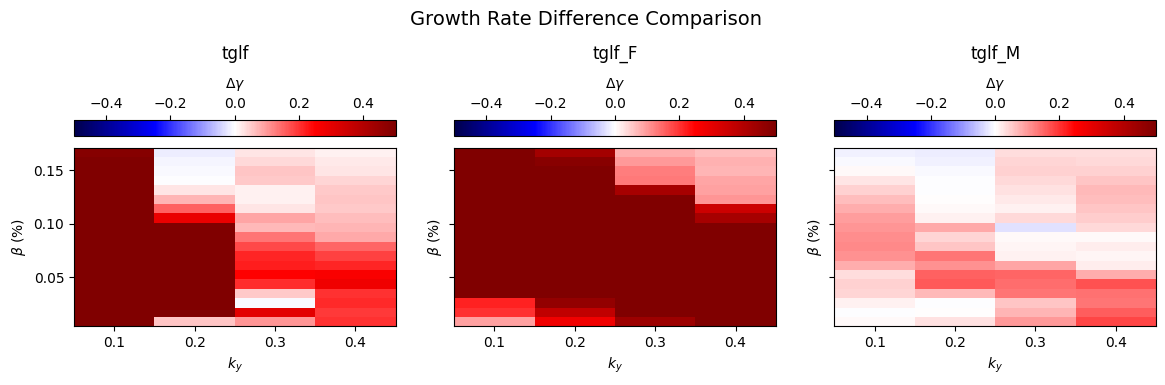

/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/Plots/Beta_Prime_Scan/R4/Growth Rate_Comparison


<Figure size 640x480 with 0 Axes>

In [48]:
fig, axes = plt.subplots(1, len(tglf_pyroscan_dict.keys()), figsize=(12, 4), sharex=True, sharey=True)
for i, (key, value) in enumerate(tglf_pyroscan_dict.items()):
    plot_growth_rate_difference(gs2_pyroscan.gk_output,
                            value.gk_output,
                            metric="absolute",
                            ax=axes[i])
    axes[i].set_title(key,y =1.45)

# plot_growth_rate_difference_GP(gs2_pyroscan.gk_output,
#                             Gaussian_Model.gk_output,
#                             metric="absolute",
#                             ax=axes[3])
# axes[3].set_title("Gaussian Model",y =1.45)

# Overall title
fig.suptitle("Growth Rate Difference Comparison", fontsize=14, y=0.95)

plt.tight_layout()
plt.show()
print(plot_location/"Growth Rate_Comparison")
plt.savefig(plot_location/"Growth Rate_Comparison")

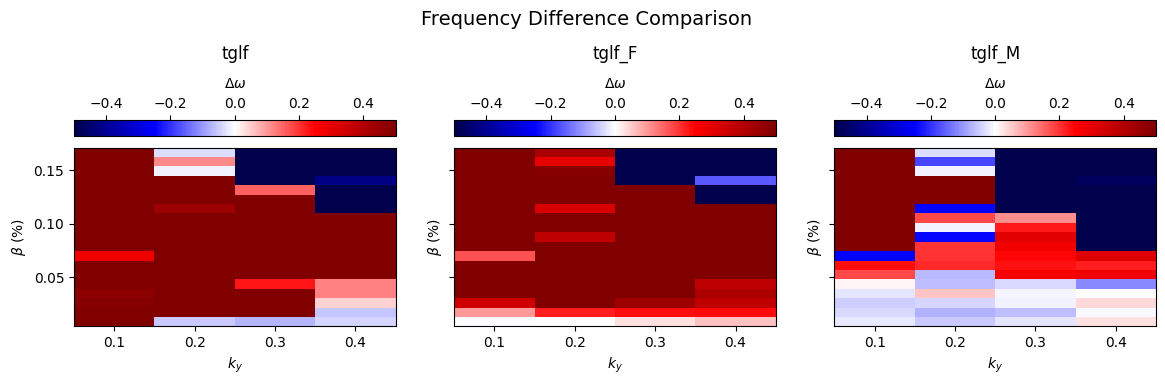

/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/Plots/Beta_Prime_Scan/R4/Frequency_Comparison


<Figure size 640x480 with 0 Axes>

In [49]:
fig, axes = plt.subplots(1, len(tglf_pyroscan_dict.keys()), figsize=(12, 4), sharex=True, sharey=True)
for i, (key, value) in enumerate(tglf_pyroscan_dict.items()):
    plot_frequency_difference(gs2_pyroscan.gk_output,
                            value.gk_output,
                            metric="absolute",
                            ax=axes[i])
    axes[i].set_title(key,y =1.45)
# plot_frequency_difference_GP(gs2_pyroscan.gk_output,
#                             Gaussian_Model.gk_output,
#                             metric="absolute",
#                             ax=axes[3])
# axes[3].set_title("Gaussian Model",y =1.45)


# Overall title
fig.suptitle("Frequency Difference Comparison", fontsize=14, y=0.95)

plt.tight_layout()
plt.show()
print(plot_location/"Frequency_Comparison")
plt.savefig(plot_location/"Frequency_Comparison")


In [ ]:
import numpy as np
import colorsys

def vector_to_rgb(dgamma, domega, magnitude=None):
    """
    Map 2D vector field (Δγ, Δω) to RGB color using HSV:
    - hue = angle of vector
    - value = magnitude (scaled to [0,1])
    - saturation = 1
    
    Parameters
    ----------
    magnitude : optional precomputed magnitude (for legend generation)

    Returns
    -------
    rgb : array (..., 3)
    vmax : float
    """
    angle = (np.arctan2(domega, dgamma) + 2*np.pi) % (2*np.pi)
    hue = angle / (2*np.pi)

    if magnitude is None:
        mag = np.sqrt(dgamma**2 + domega**2)
    else:
        mag = magnitude

    vmax = np.nanpercentile(mag, 99)
    val = np.clip(mag / vmax, 0, 1)

    sat = np.ones_like(val)

    rgb = np.zeros(mag.shape + (3,))
    it = np.nditer(val, flags=["multi_index"])
    for v in it:
        idx = it.multi_index
        rgb[idx] = colorsys.hsv_to_rgb(hue[idx], sat[idx], val[idx])

    return rgb, vmax


In [ ]:
def add_2d_legend(fig, size=100, vmax=None, label=r"$ (\Delta \gamma, \Delta \omega)$"):
    """
    Add a 2D legend panel that shows the hue/magnitude mapping.
    """

    # Vector grid in normalized error space
    g = np.linspace(-1, 1, size)
    G, W = np.meshgrid(g, g)

    mag = np.sqrt(G**2 + W**2)
    if vmax is None:
        vmax = np.nanmax(mag)

    rgb, _ = vector_to_rgb(G, W, magnitude=mag)

    ax = fig.add_axes([0.8, 0.55, 0.15, 0.35])
    ax.imshow(
        rgb,
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal"
    )
    ax.set_xlabel(r"$\Delta \gamma$")
    ax.set_ylabel(r"$\Delta \omega$")
    ax.set_title("2D Error Map", fontsize=10)

    return ax


In [ ]:
import matplotlib.pyplot as plt

def plot_combined_error(
    gs2_output,
    tglf_output,
    metric="absolute",
    fig=None,
    ax=None,
    title=None
):
    """
    Create a 2D (ky, beta) grid plot where color encodes BOTH Δγ and Δω.
    
    - Supports absolute and relative error
    - Works with multi-panel layouts (pass fig, ax)
    """

    # Create figure/axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))

    ky = gs2_output.coords["ky"].data
    beta = gs2_output.coords["beta"].data

    gr_gs2 = gs2_output["growth_rate"].data.magnitude
    om_gs2 = gs2_output["mode_frequency"].data.magnitude

    gr_tglf = tglf_output["growth_rate"].sel(mode=0).data.magnitude
    om_tglf = tglf_output["mode_frequency"].sel(mode=0).data.magnitude

    # Differences
    dgamma = gr_tglf - gr_gs2
    domega = om_tglf - om_gs2

    if metric == "relative":
        dgamma = dgamma / np.abs(gr_gs2)
        domega = domega / np.abs(om_gs2)

    # Convert to color grid
    rgb, vmax = vector_to_rgb(dgamma, domega)

    # Render grid
    ax.imshow(
        rgb,
        extent=[beta.min(), beta.max(), ky.min(), ky.max()],
        aspect="auto",
        origin="lower"
    )

    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$k_y$")

    if title:
        ax.set_title(title)

    return fig, ax, vmax


In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

models = ["tglf", "tglf_M", "tglf_F"]

for i, name in enumerate(models):
    fig, ax, vmax = plot_combined_error(
        gs2_pyroscan.gk_output,
        tglf_pyroscan_dict[name].gk_output,
        metric="absolute",
        fig=fig,
        ax=axs[i],
        title=name
    )

# Add 2D legend
add_2d_legend(fig)

plt.tight_layout()
plt.show()
